# Phishing Website Detection

## Project Description
This project uses machine learning to detect phishing websites.
We train models to classify websites as phishing or legitimate.
We use two datasets to make our model more reliable.

## Datasets
- **Kaggle:** 10,000 websites, 48 features
- **UCI:** 11,055 websites, 30 features

## Project Roadmap

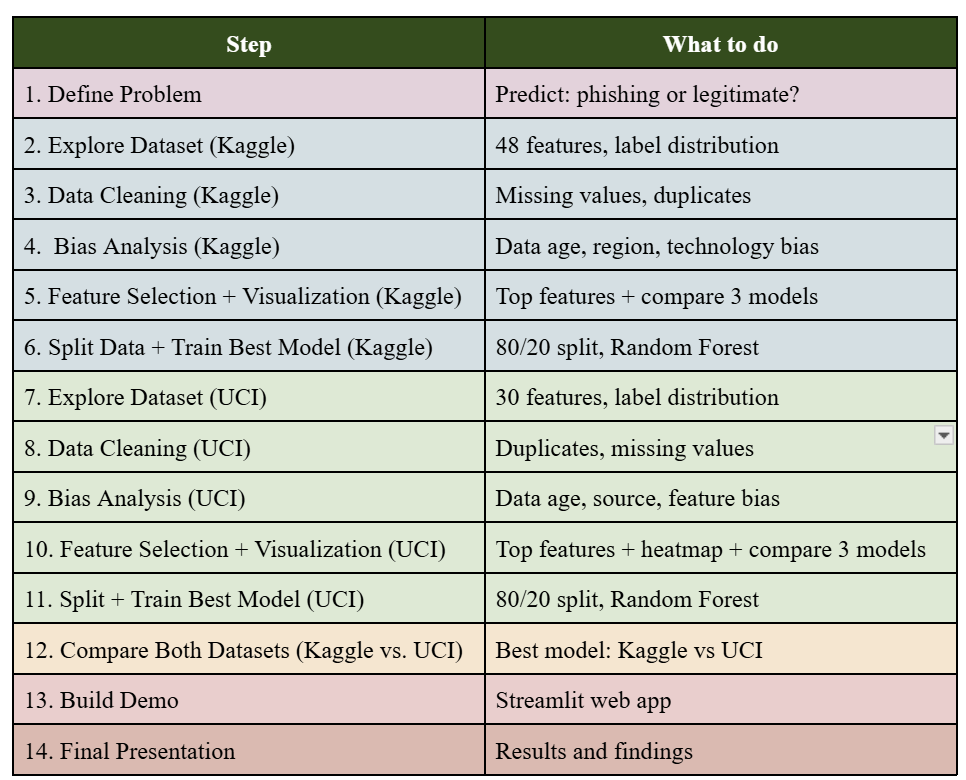


Dataset loaded! Shape: (10000, 50)

--------------------------------------- First 5 Rows (Kaggle) ---------------------------------------


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,id,1.00,2.00,3.00,4.00,5.00,NumSensitiveWords,0.00,1.00,0.00,0.00,0.00
1,NumDots,3.00,3.00,3.00,3.00,3.00,EmbeddedBrandName,0.00,0.00,0.00,1.00,0.00
2,SubdomainLevel,1.00,1.00,1.00,1.00,0.00,PctExtHyperlinks,0.00,0.00,0.38,1.00,1.00
3,PathLevel,5.00,3.00,2.00,6.00,4.00,PctExtResourceUrls,0.25,0.00,1.00,0.10,1.00
4,UrlLength,72.00,144.00,58.00,79.00,46.00,ExtFavicon,1.00,0.00,1.00,1.00,0.00
5,NumDash,0.00,0.00,0.00,1.00,0.00,InsecureForms,1.00,1.00,1.00,1.00,0.00
6,NumDashInHostname,0.00,0.00,0.00,0.00,0.00,RelativeFormAction,0.00,0.00,0.00,0.00,0.00
7,AtSymbol,0.00,0.00,0.00,0.00,0.00,ExtFormAction,0.00,0.00,0.00,0.00,1.00
8,TildeSymbol,0.00,0.00,0.00,0.00,0.00,AbnormalFormAction,0.00,0.00,0.00,0.00,0.00
9,NumUnderscore,0.00,2.00,0.00,0.00,0.00,PctNullSelfRedirectHyperlinks,0.00,0.00,0.00,0.00,0.00



--------------------------------------- Label Count (Kaggle) ---------------------------------------


,count
CLASS_LABEL,
Phishing,5000
Legitimate,5000


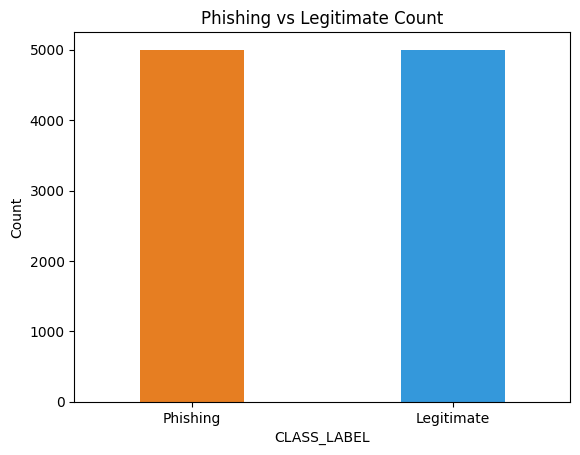


--------------------------------------- Missing Values (Kaggle) ---------------------------------------


,Feature,Missing,Feature,Missing,Feature,Missing
0,id,0,IpAddress,0,PctNullSelfRedirectHyperlinks,0.0
1,NumDots,0,DomainInSubdomains,0,FrequentDomainNameMismatch,0.0
2,SubdomainLevel,0,DomainInPaths,0,FakeLinkInStatusBar,0.0
3,PathLevel,0,HttpsInHostname,0,RightClickDisabled,0.0
4,UrlLength,0,HostnameLength,0,PopUpWindow,0.0
5,NumDash,0,PathLength,0,SubmitInfoToEmail,0.0
6,NumDashInHostname,0,QueryLength,0,IframeOrFrame,0.0
7,AtSymbol,0,DoubleSlashInPath,0,MissingTitle,0.0
8,TildeSymbol,0,NumSensitiveWords,0,ImagesOnlyInForm,0.0
9,NumUnderscore,0,EmbeddedBrandName,0,SubdomainLevelRT,0.0



--------------------------------------- Stats Summary (Kaggle) ---------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.50,2886.90,1.0,2500.75,5000.50,7500.25,10000.0
NumDots,10000.0,2.45,1.35,1.0,2.00,2.00,3.00,21.0
SubdomainLevel,10000.0,0.59,0.75,0.0,0.00,1.00,1.00,14.0
PathLevel,10000.0,3.30,1.86,0.0,2.00,3.00,4.00,18.0
UrlLength,10000.0,70.26,33.37,12.0,48.00,62.00,84.00,253.0
NumDash,10000.0,1.82,3.11,0.0,0.00,0.00,2.00,55.0
NumDashInHostname,10000.0,0.14,0.55,0.0,0.00,0.00,0.00,9.0
AtSymbol,10000.0,0.00,0.02,0.0,0.00,0.00,0.00,1.0
TildeSymbol,10000.0,0.01,0.11,0.0,0.00,0.00,0.00,1.0
NumUnderscore,10000.0,0.32,1.11,0.0,0.00,0.00,0.00,18.0


In [11]:
# Step 2: Explore Dataset (Kaggle)
# Goal: load the data and look at it before cleaning.
import pandas as pd
import matplotlib.pyplot as plt

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

# Load Kaggle dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')
print("Dataset loaded! Shape:", df.shape)   # rows, columns

# === First 5 Rows ===
# Transpose + split into 2 groups (25 + 25) so it's not too long
print("\n--------------------------------------- First 5 Rows (Kaggle) ---------------------------------------")
head_T = df.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 25
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"'))

# === Label Count ===
# 1 = Phishing, 0 = Legitimate
print("\n--------------------------------------- Label Count (Kaggle) ---------------------------------------")
label_df = df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).to_frame()
display(label_df.style.set_table_attributes('style="width:1000px"'))

# Bar chart. Easy to see the 50/50 balance.
df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).plot(
    kind='bar',
    color=['#e67e22', '#3498db'],
    width=0.4,
    title='Phishing vs Legitimate Count'
)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# === Missing Values ===
# Check all 50 columns. Split into 3 groups (17 + 17 + 16) so it's not too long.
print("\n--------------------------------------- Missing Values (Kaggle) ---------------------------------------")
missing = df.isnull().sum()
n = 17
mgroups = []
for i in range(0, len(missing), n):
    g = missing.iloc[i:i+n].reset_index()
    g.columns = ['Feature', 'Missing']
    mgroups.append(g.reset_index(drop=True))
missing_wide = pd.concat(mgroups, axis=1).fillna('')
display(missing_wide)

# === Stats Summary ===
# Basic stats for each column (min, max, mean, etc.)
print("\n--------------------------------------- Stats Summary (Kaggle) ---------------------------------------")
display(df.describe().round(2).T)

## Step 2 Summary - Explore Dataset (Kaggle)

### What we found:
- Total data: **10,000 websites** (5,000 phishing + 5,000 legitimate)
- Total features: **48 features** (50 columns with id + label)
- Missing values: **None** (data is clean)
- Labels are **perfectly balanced** (50% vs 50%)

### What this means:
- Data is ready for cleaning
- No need to fix missing values
- Balanced data = fair model training

### Next step:
-> Step 3: Data Cleaning (Kaggle) 

In [12]:
# Step 3: Data Cleaning (Kaggle)
import pandas as pd

# Load Kaggle dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')

# Check duplicates
print("-------------------- Duplicates --------------------")
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Check missing values
print("\n-------------------- Missing Values --------------------")
print(df.isnull().sum().sum(), "total missing values")

# Drop 'id' column (just a row number, not useful for training)
df = df.drop(columns=['id'])
print("\nDropped 'id' column")
print("New shape:", df.shape)

# Final check
print("\n-------------------- Clean Dataset Ready --------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Show head, split into 2 groups (so it's not too long)
head_T = df.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 25
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

caption_style = [{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', 'black')]}]
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"').set_caption("First 5 Rows (Clean Dataset)").set_table_styles(caption_style))

-------------------- Duplicates --------------------
Duplicate rows: 0
After removing duplicates: (10000, 50)

-------------------- Missing Values --------------------
0 total missing values

Dropped 'id' column
New shape: (10000, 49)

-------------------- Clean Dataset Ready --------------------
Rows: 10000
Columns: 49


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,NumDots,3.00,3.00,3.00,3.00,3.00,EmbeddedBrandName,0.00,0.00,0.00,1.00,0.00
1,SubdomainLevel,1.00,1.00,1.00,1.00,0.00,PctExtHyperlinks,0.00,0.00,0.38,1.00,1.00
2,PathLevel,5.00,3.00,2.00,6.00,4.00,PctExtResourceUrls,0.25,0.00,1.00,0.10,1.00
3,UrlLength,72.00,144.00,58.00,79.00,46.00,ExtFavicon,1.00,0.00,1.00,1.00,0.00
4,NumDash,0.00,0.00,0.00,1.00,0.00,InsecureForms,1.00,1.00,1.00,1.00,0.00
5,NumDashInHostname,0.00,0.00,0.00,0.00,0.00,RelativeFormAction,0.00,0.00,0.00,0.00,0.00
6,AtSymbol,0.00,0.00,0.00,0.00,0.00,ExtFormAction,0.00,0.00,0.00,0.00,1.00
7,TildeSymbol,0.00,0.00,0.00,0.00,0.00,AbnormalFormAction,0.00,0.00,0.00,0.00,0.00
8,NumUnderscore,0.00,2.00,0.00,0.00,0.00,PctNullSelfRedirectHyperlinks,0.00,0.00,0.00,0.00,0.00
9,NumPercent,0.00,0.00,0.00,0.00,0.00,FrequentDomainNameMismatch,0.00,0.00,0.00,1.00,1.00


## Step 3 Summary - Data Cleaning (Kaggle)

### What we did:
- Checked duplicate rows and removed them
- Checked missing values
- Dropped the `id` column (just a row number, not useful for training)

### What we found:
- Duplicate rows: **0** (no duplicates)
- Missing values: **0** (data is complete)
- Final shape: **10,000 rows, 49 columns** (48 features + label)

### What this means:
- Data is clean and ready
- No duplicates = no repeated data
- No missing values = no empty data
- Dropping `id` = model focuses on real features only

### Next step:
-> Step 4: Bias Analysis (Kaggle)

## Step 4: Bias Analysis (Kaggle)

### What is bias?
Bias means our data or model may not be fair or correct for every case.

### Sources of bias in the Kaggle dataset:

**1. Time Bias**
- The data was collected a few years ago
- Phishing tricks change fast
- New attack types may not be in the data

**2. Region Bias**
- We don't know which countries or languages the sites are from
- Phishing patterns can differ by region

**3. Feature Bias**
- Only 48 features were collected
- Some new phishing signs may not be covered

### How we reduce bias:
- Use a balanced dataset (5,000 phishing + 5,000 legitimate)
- Test 3 different models and compare
- Use 80/20 train/test split for fair evaluation
- Also test on a second dataset (UCI) to check our model

### Next step:
-> Step 5: Feature Selection + Visualization (Kaggle)

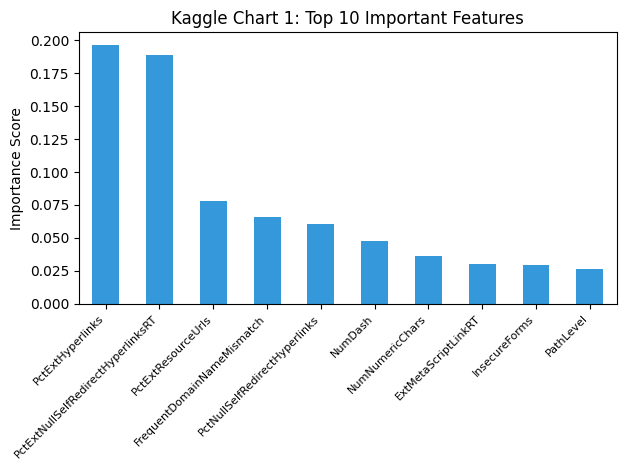

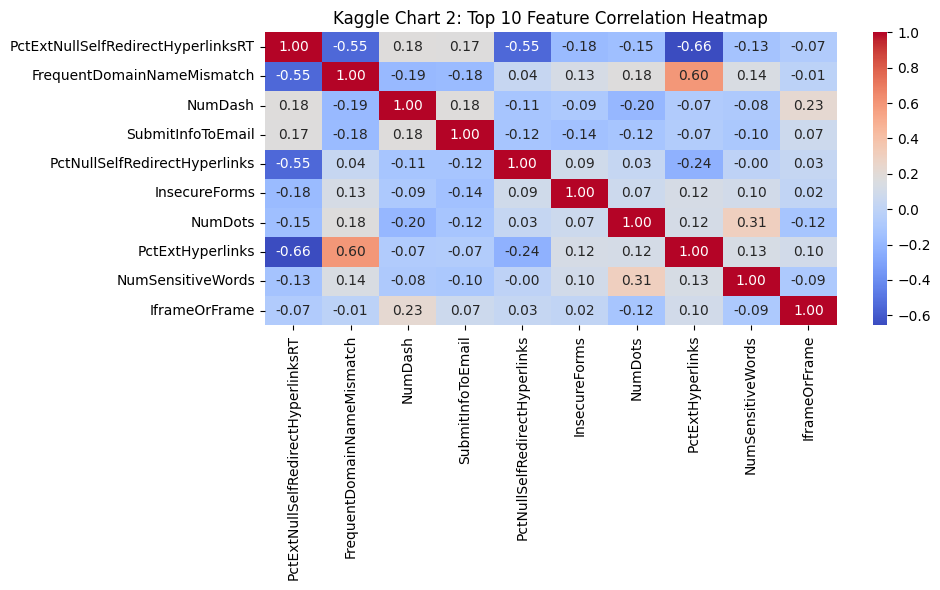

------------------------ Kaggle Model Comparison ------------------------
Logistic Regression: 95.20%
Decision Tree: 96.40%
Random Forest: 98.55%


In [13]:
# Step 5: Feature Selection + Visualization (Kaggle)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load clean data
df = pd.read_csv('Phishing_Legitimate_full.csv')
df = df.drop(columns=['id'])

# X = features (input), y = label (output)
X = df.drop(columns=['CLASS_LABEL'])
y = df['CLASS_LABEL']

# Chart 1: Top 10 important features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)[:10].plot(
    kind='bar', color='#3498db', title='Kaggle Chart 1: Top 10 Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Chart 2: Correlation heatmap (top 10 features most related to label)
top_features = df.corr()['CLASS_LABEL'].abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Kaggle Chart 2: Top 10 Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Compare 3 models (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
print("------------------------ Kaggle Model Comparison ------------------------")
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc*100:.2f}%")

## Step 5 Summary - Feature Selection + Visualization (Kaggle)

### What we found:

**Chart 1: Top 10 Important Features**
- PctExtHyperlinks is the most important feature
- These features are about suspicious links in websites

**Chart 2: Correlation Heatmap**
- Red = features that work together
- Blue = features that are opposite

**Model Comparison Results:**

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 95.20% |
| Decision Tree | 96.40% |
| Random Forest | 98.55% |

### Conclusion:
- Random Forest is the best model (98.55%)
- It correctly detects about 98 out of 100 websites

### Next step:
-> Step 6: Split Data + Train Best Model (Kaggle)

Kaggle Accuracy: 98.55 %

=== Report ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1000
    Phishing       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



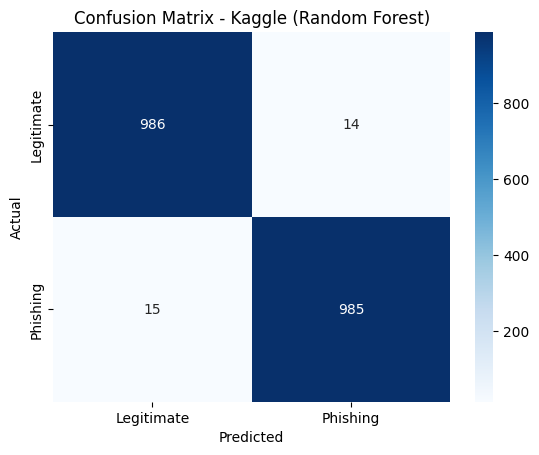

In [14]:
# Step 6: Split Data + Train Best Model (Kaggle)
# Use Kaggle data. Train Random Forest (best from Step 5). Check results.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data. stratify keeps 50/50 balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest (best model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test data
y_pred = rf.predict(X_test)

# Accuracy
kaggle_acc = accuracy_score(y_test, y_pred)
print("Kaggle Accuracy:", round(kaggle_acc * 100, 2), "%")

# Full report. Recall = how many phishing sites we caught. This matters most.
print("\n=== Report ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion matrix. Shows right vs wrong predictions.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Kaggle (Random Forest)')
plt.show()

## Step 6 Summary - Split Data + Train Best Model (Kaggle)

### What we found:

**Accuracy:** 98.55%

**Report (Phishing class):**
- Precision = 98.60% (when it says phishing, it is right 98.60% of the time)
- Recall = 98.50% (it catches 98.50% of phishing sites)

**Confusion Matrix:**

| | Predicted Legit | Predicted Phishing |
|---|---|---|
| Actual Legit | 986 (correct) | 14 (false alarm) |
| Actual Phishing | 15 (missed) | 985 (caught) |

### What this means:
- The model catches almost all phishing sites
- It misses only 15 phishing sites out of 1000
- False alarms are low (only 14)

### Conclusion:
- Random Forest works very well on the Kaggle data
- High recall is good. We do not want to miss phishing sites.

### Next step:
-> Step 7: Explore Dataset (UCI)

UCI loaded! Shape: (11055, 31)

--------------------------------------- First 5 Rows (UCI) ---------------------------------------


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,having_ip_address,-1.00,1.00,1.00,1.00,1.00,submitting_to_email,-1.00,1.00,-1.00,1.00,1.00
1,url_length,1.00,1.00,0.00,0.00,0.00,abnormal_url,-1.00,1.00,-1.00,1.00,1.00
2,shortining_service,1.00,1.00,1.00,1.00,-1.00,redirect,0.00,0.00,0.00,0.00,0.00
3,having_at_symbol,1.00,1.00,1.00,1.00,1.00,on_mouseover,1.00,1.00,1.00,1.00,-1.00
4,double_slash_redirecting,-1.00,1.00,1.00,1.00,1.00,rightclick,1.00,1.00,1.00,1.00,1.00
5,prefix_suffix,-1.00,-1.00,-1.00,-1.00,-1.00,popupwindow,1.00,1.00,1.00,1.00,-1.00
6,having_sub_domain,-1.00,0.00,-1.00,-1.00,1.00,iframe,1.00,1.00,1.00,1.00,1.00
7,sslfinal_state,-1.00,1.00,-1.00,-1.00,1.00,age_of_domain,-1.00,-1.00,1.00,-1.00,-1.00
8,domain_registration_length,-1.00,-1.00,-1.00,1.00,-1.00,dnsrecord,-1.00,-1.00,-1.00,-1.00,-1.00
9,favicon,1.00,1.00,1.00,1.00,1.00,web_traffic,-1.00,0.00,1.00,1.00,0.00



--------------------------------------- Label Count (UCI) ---------------------------------------


,count
Result,
1,6157
-1,4898


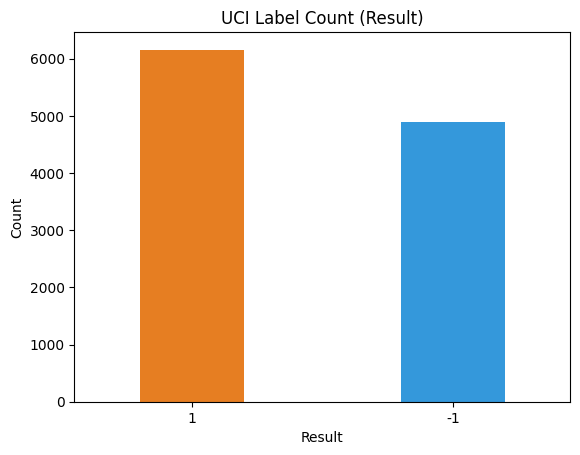


--------------------------------------- Missing Values (UCI) ---------------------------------------


,Feature,Missing,Feature,Missing
0,having_ip_address,0,submitting_to_email,0.0
1,url_length,0,abnormal_url,0.0
2,shortining_service,0,redirect,0.0
3,having_at_symbol,0,on_mouseover,0.0
4,double_slash_redirecting,0,rightclick,0.0
5,prefix_suffix,0,popupwindow,0.0
6,having_sub_domain,0,iframe,0.0
7,sslfinal_state,0,age_of_domain,0.0
8,domain_registration_length,0,dnsrecord,0.0
9,favicon,0,web_traffic,0.0



--------------------------------------- Stats Summary (UCI) ---------------------------------------


,count,mean,std,min,25%,50%,75%,max
having_ip_address,11055.0,0.31,0.95,-1.0,-1.0,1.0,1.0,1.0
url_length,11055.0,-0.63,0.77,-1.0,-1.0,-1.0,-1.0,1.0
shortining_service,11055.0,0.74,0.67,-1.0,1.0,1.0,1.0,1.0
having_at_symbol,11055.0,0.70,0.71,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.74,0.67,-1.0,1.0,1.0,1.0,1.0
prefix_suffix,11055.0,-0.73,0.68,-1.0,-1.0,-1.0,-1.0,1.0
having_sub_domain,11055.0,0.06,0.82,-1.0,-1.0,0.0,1.0,1.0
sslfinal_state,11055.0,0.25,0.91,-1.0,-1.0,1.0,1.0,1.0
domain_registration_length,11055.0,-0.34,0.94,-1.0,-1.0,-1.0,1.0,1.0
favicon,11055.0,0.63,0.78,-1.0,1.0,1.0,1.0,1.0


In [15]:
# Step 7: Explore Dataset (UCI)
# Goal: download UCI and look at it before cleaning.
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

# Download UCI dataset (11,055 sites, 30 features)
uci = fetch_ucirepo(id=327)
df_uci = uci.data.features.copy()
df_uci['Result'] = uci.data.targets.values.ravel()

# Save raw data for next steps
df_uci.to_csv('uci_raw.csv', index=False)
print("UCI loaded! Shape:", df_uci.shape)   # rows, columns

# === First 5 Rows ===
# Transpose + split into 2 groups so it's not too long
print("\n--------------------------------------- First 5 Rows (UCI) ---------------------------------------")
head_T = df_uci.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 16
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"'))

# === Label Count ===
# UCI label is -1 and 1 (check .docx for which is phishing)
print("\n--------------------------------------- Label Count (UCI) ---------------------------------------")
label_df = df_uci['Result'].value_counts().to_frame()
display(label_df.style.set_table_attributes('style="width:1000px"'))

# Bar chart
df_uci['Result'].value_counts().plot(
    kind='bar',
    color=['#e67e22', '#3498db'],
    width=0.4,
    title='UCI Label Count (Result)'
)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# === Missing Values ===
# Check all 31 columns. Split into 2 groups.
print("\n--------------------------------------- Missing Values (UCI) ---------------------------------------")
missing = df_uci.isnull().sum()
n = 16
mgroups = []
for i in range(0, len(missing), n):
    g = missing.iloc[i:i+n].reset_index()
    g.columns = ['Feature', 'Missing']
    mgroups.append(g.reset_index(drop=True))
missing_wide = pd.concat(mgroups, axis=1).fillna('')
display(missing_wide)

# === Stats Summary ===
print("\n--------------------------------------- Stats Summary (UCI) ---------------------------------------")
display(df_uci.describe().round(2).T)

## Step 7 Summary - Explore Dataset (UCI)

### What we found:
- Total data: **11,055 websites**
- Total columns: **31** (30 features + label)
- Missing values: **None** (data is complete)
- All features are encoded as **-1 / 0 / 1**
- Label: **1 = Phishing (6,157)**, **-1 = Legitimate (4,898)**
- Balance: **56% phishing, 44% legitimate** (not perfectly 50/50)

### What this means:
- Different format from Kaggle (30 features vs 48, label is -1/1)
- No missing values to fix
- Slightly more phishing than legitimate, but still fairly balanced
- Next we clean duplicates, then map the label to 0/1

### Next step:
-> Step 8: Data Cleaning (UCI)

In [16]:
# Step 8: Data Cleaning (UCI)
import pandas as pd

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

# Load raw UCI data (from Step 7)
df_uci = pd.read_csv('uci_raw.csv')

# Check duplicates
print("-------------------- Duplicates --------------------")
print("Duplicate rows:", df_uci.duplicated().sum())

# Remove duplicates
df_uci = df_uci.drop_duplicates()
print("After removing duplicates:", df_uci.shape)

# Check missing values
print("\n-------------------- Missing Values --------------------")
print(df_uci.isnull().sum().sum(), "total missing values")

# UCI has no 'id' column, nothing to drop

# Save clean data
df_uci.to_csv('uci_phishing.csv', index=False)

# Final check
print("\n-------------------- Clean Dataset Ready --------------------")
print("Rows:", df_uci.shape[0])
print("Columns:", df_uci.shape[1])

# Show head, split into 2 groups (so it's not too long)
head_T = df_uci.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 16
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')

caption_style = [{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', 'black')]}]
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"').set_caption("First 5 Rows (Clean UCI Dataset)").set_table_styles(caption_style))

-------------------- Duplicates --------------------
Duplicate rows: 5206
After removing duplicates: (5849, 31)

-------------------- Missing Values --------------------
0 total missing values

-------------------- Clean Dataset Ready --------------------
Rows: 5849
Columns: 31


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,having_ip_address,-1.00,1.00,1.00,1.00,1.00,submitting_to_email,-1.00,1.00,-1.00,1.00,1.00
1,url_length,1.00,1.00,0.00,0.00,0.00,abnormal_url,-1.00,1.00,-1.00,1.00,1.00
2,shortining_service,1.00,1.00,1.00,1.00,-1.00,redirect,0.00,0.00,0.00,0.00,0.00
3,having_at_symbol,1.00,1.00,1.00,1.00,1.00,on_mouseover,1.00,1.00,1.00,1.00,-1.00
4,double_slash_redirecting,-1.00,1.00,1.00,1.00,1.00,rightclick,1.00,1.00,1.00,1.00,1.00
5,prefix_suffix,-1.00,-1.00,-1.00,-1.00,-1.00,popupwindow,1.00,1.00,1.00,1.00,-1.00
6,having_sub_domain,-1.00,0.00,-1.00,-1.00,1.00,iframe,1.00,1.00,1.00,1.00,1.00
7,sslfinal_state,-1.00,1.00,-1.00,-1.00,1.00,age_of_domain,-1.00,-1.00,1.00,-1.00,-1.00
8,domain_registration_length,-1.00,-1.00,-1.00,1.00,-1.00,dnsrecord,-1.00,-1.00,-1.00,-1.00,-1.00
9,favicon,1.00,1.00,1.00,1.00,1.00,web_traffic,-1.00,0.00,1.00,1.00,0.00


## Step 8 Summary - Data Cleaning (UCI)

### What we did:
- Checked duplicate rows and removed them
- Checked missing values
- UCI has no `id` column, so nothing to drop

### What we found:
- Duplicate rows: **5,206** (almost half the data!)
- Missing values: **0**
- Final shape: **5,849 rows, 31 columns**

### What this means:
- UCI had many duplicate rows (Kaggle had none)
- Removing them is important. Duplicates can leak between train and test and make accuracy look too high.
- Data is now clean and ready

### Next step:
-> Step 9: Bias Analysis (UCI)

## Step 9: Bias Analysis (UCI)

### What is bias?
Bias means our data or model may not be fair or correct for every case.

### Sources of bias in the UCI dataset:

**1. Time Bias**
- UCI data is from 2015 (older than Kaggle)
- Phishing tricks change fast
- Old data may miss new attack types

**2. Source Bias**
- Data is from PhishTank, MillerSmiles, and Google search
- May not cover all phishing types or regions

**3. Feature Bias**
- Only 30 features (Kaggle has 48)
- Some new phishing signs may not be covered

**4. Label Balance**
- Not perfectly 50/50 (56% phishing, 44% legitimate)
- A bit more phishing than legitimate

### How we reduce bias:
- Use stratify in the train/test split (keeps the same balance)
- Test 3 different models and compare
- Use a second dataset (Kaggle) to check our results
- Similar results on both datasets = more reliable

### Next step:
-> Step 10: Feature Selection + Visualization (UCI)

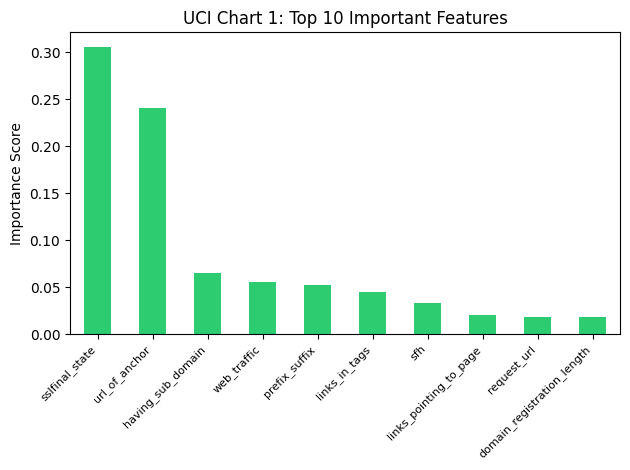

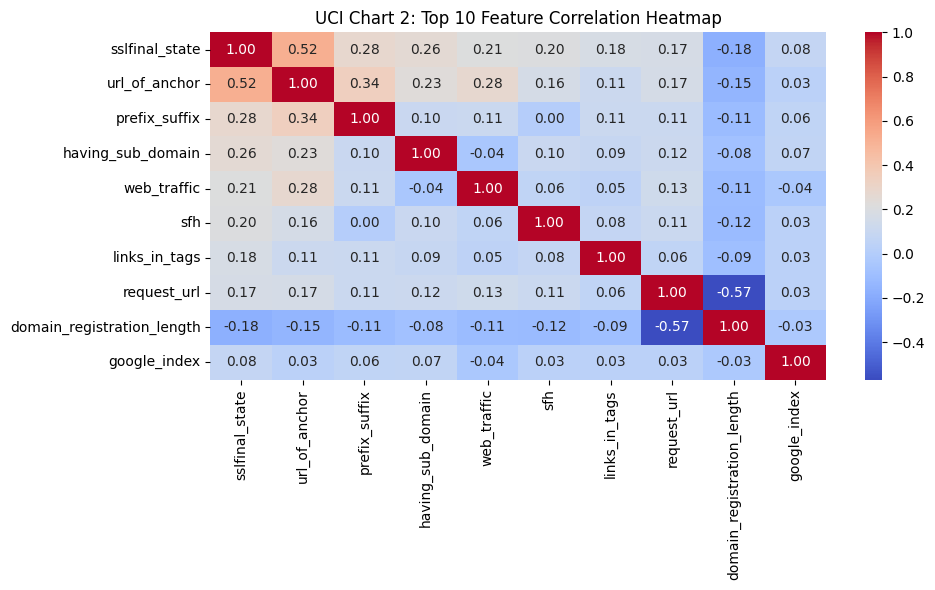

-------------------- UCI Model Comparison --------------------
Logistic Regression: 91.28%
Decision Tree: 91.71%
Random Forest: 94.19%


In [17]:
# Step 10: Feature Selection + Visualization (UCI)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load clean UCI data
df_uci = pd.read_csv('uci_phishing.csv')

# X = features, y = label. UCI uses -1 and 1. Make it 0=Legit, 1=Phishing.
X_uci = df_uci.drop(columns=['Result'])
y_uci = df_uci['Result'].map({1: 1, -1: 0})

# Chart 1: Top 10 important features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_uci, y_uci)
importances = pd.Series(rf.feature_importances_, index=X_uci.columns)
importances.sort_values(ascending=False)[:10].plot(
    kind='bar', color='#2ecc71', title='UCI Chart 1: Top 10 Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Chart 2: Correlation heatmap (top 10 features most related to label)
df_corr = X_uci.copy()
df_corr['Result'] = y_uci
top_features = df_corr.corr()['Result'].abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('UCI Chart 2: Top 10 Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Compare 3 models (80/20 split, stratify keeps balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42, stratify=y_uci)
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
print("-------------------- UCI Model Comparison --------------------")
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc*100:.2f}%")

## Step 10 Summary - Feature Selection + Visualization (UCI)

### What we found:

**Chart 1: Top 10 Important Features**
- sslfinal_state is the most important feature (0.31)
- url_of_anchor is second (0.24)
- These are about SSL status and link safety

**Chart 2: Correlation Heatmap**
- sslfinal_state and url_of_anchor are related (0.52)
- Red = work together, Blue = opposite

**Model Comparison Results (clean data, 5,849 rows):**

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 91.28% |
| Decision Tree | 91.71% |
| Random Forest | 94.19% |

### Conclusion:
- Random Forest is the best model on UCI too (94.19%)
- Note: lower than the duplicated data, because removing duplicates gives a fair, honest score
- High accuracy on a second dataset = our method is reliable

### Next step:
-> Step 11: Split + Train Best Model (UCI)

UCI Accuracy: 94.19 %

------------------------------ Report -----------------------------
              precision    recall  f1-score   support

  Legitimate       0.95      0.94      0.94       604
    Phishing       0.94      0.94      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



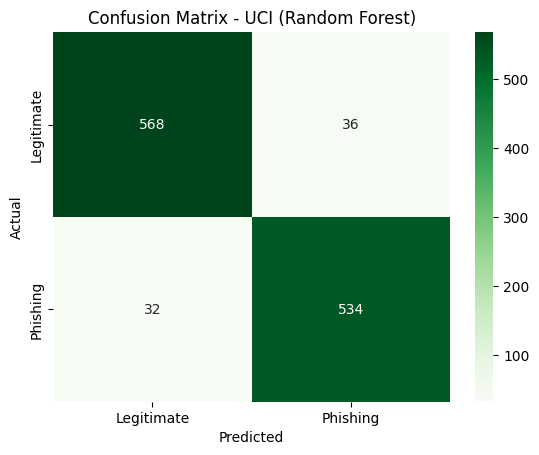

In [18]:
# Step 11: Split + Train Best Model (UCI)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean UCI data
df_uci = pd.read_csv('uci_phishing.csv')
X_uci = df_uci.drop(columns=['Result'])
y_uci = df_uci['Result'].map({1: 1, -1: 0})   # 0=Legit, 1=Phishing

# Split data. stratify keeps the same balance.
Xu_train, Xu_test, yu_train, yu_test = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42, stratify=y_uci)

# Train Random Forest (best model)
rf_uci = RandomForestClassifier(n_estimators=100, random_state=42)
rf_uci.fit(Xu_train, yu_train)
yu_pred = rf_uci.predict(Xu_test)

# Accuracy
uci_acc = accuracy_score(yu_test, yu_pred)
print("UCI Accuracy:", round(uci_acc * 100, 2), "%")

# Full report. Recall = how many phishing sites we caught. This matters most.
print("\n------------------------------ Report -----------------------------")
print(classification_report(yu_test, yu_pred, target_names=['Legitimate', 'Phishing']))

# Confusion matrix. Shows right vs wrong predictions.
cm = confusion_matrix(yu_test, yu_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - UCI (Random Forest)')
plt.show()

## Step 11 Summary - Split + Train Best Model (UCI)

### What we found:

**Accuracy:** 94.19%

**Report (Phishing class):**
- Precision = 93.68% (when it says phishing, it is right 93.68% of the time)
- Recall = 94.35% (it catches 94.35% of phishing sites)

**Confusion Matrix:**

| | Predicted Legit | Predicted Phishing |
|---|---|---|
| Actual Legit | 568 (correct) | 36 (false alarm) |
| Actual Phishing | 32 (missed) | 534 (caught) |

### What this means:
- The model works well on the second dataset too
- It misses only 32 phishing sites out of 566
- Recall is high (94.35%) - good for catching phishing

### Conclusion:
- Random Forest works well on UCI (94.19%)
- Lower than Kaggle (98.55%) but still strong
- Our method works on two different datasets

### Next step:
-> Step 12: Compare Both Datasets

---------------------------------------- Both Datasets: 3 Models ----------------------------------------


,Model,Kaggle (%),UCI (%)
0,Logistic Regression,95.20,91.28
1,Decision Tree,96.40,91.71
2,Random Forest,98.55,94.19


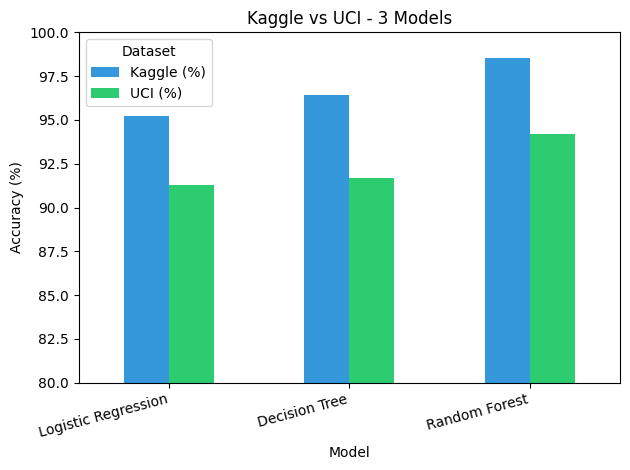

In [21]:
# Step 12: Compare Both Datasets
# Put Kaggle and UCI side by side. Same 3 models.
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

# Load both clean datasets (so this cell works on its own)
df_k = pd.read_csv('Phishing_Legitimate_full.csv').drop(columns=['id'])
X = df_k.drop(columns=['CLASS_LABEL'])
y = df_k['CLASS_LABEL']

df_u = pd.read_csv('uci_phishing.csv')
X_uci = df_u.drop(columns=['Result'])
y_uci = df_u['Result'].map({1: 1, -1: 0})

# Helper: train 3 models, return accuracy for each
def get_scores(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
    models = {
        'Logistic Regression': LogisticRegression(max_iter=5000),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }
    return {name: round(accuracy_score(yte, m.fit(Xtr, ytr).predict(Xte)) * 100, 2)
            for name, m in models.items()}

kaggle_scores = get_scores(X, y)
uci_scores = get_scores(X_uci, y_uci)

# Comparison table
compare = pd.DataFrame({
    'Model': list(kaggle_scores.keys()),
    'Kaggle (%)': list(kaggle_scores.values()),
    'UCI (%)': list(uci_scores.values())
})
print("---------------------------------------- Both Datasets: 3 Models ----------------------------------------")
display(compare.style.format(fmt).set_table_attributes('style="width:600px"'))

# Grouped bar chart
compare.plot(x='Model', y=['Kaggle (%)', 'UCI (%)'],
             kind='bar', color=['#3498db', '#2ecc71'])
plt.ylim(80, 100)
plt.ylabel('Accuracy (%)')
plt.title('Kaggle vs UCI - 3 Models')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

## Step 12 Summary - Compare Both Datasets

### What we found:

We trained the same 3 models on both datasets (after cleaning).

| Model | Kaggle | UCI |
|-------|--------|-----|
| Logistic Regression | 95.20% | 91.28% |
| Decision Tree | 96.40% | 91.71% |
| Random Forest | 98.55% | 94.19% |

### What this means:
- Random Forest is the best model on both datasets
- Kaggle scores are a bit higher than UCI
- Both datasets give strong results (over 94% for Random Forest)
- The model works on different data, not just one

### Conclusion:
- Random Forest is our final model
- It works well on two independent datasets
- Our phishing detection method is reliable and robust

### Project done. Next: build demo + final presentation.